<a href="https://colab.research.google.com/github/islemkaddoussi/Mamba/blob/main/SSM_VS_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB

Creating models...


/tmp/ipykernel_800/570420457.py:86: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(



Transformer params : 3.16M
SSM params         : 0.40M


       L |    Transformer |          SSM |      T-MEM |      S-MEM | Speedup
────────────────────────────────────────────────────────────────────────────────

Testing sequence length = 256


W0524 10:47:12.172000 800 torch/_inductor/utils.py:1679] [1/0] Not enough SMs to use max_autotune_gemm mode


     256 |       16.64 ms |      2.17 ms |       62 MB |       45 MB | 🟢 7.66×

Testing sequence length = 512
     512 |       26.10 ms |      2.12 ms |       99 MB |       66 MB | 🟢 12.29×

Testing sequence length = 1024
    1024 |       67.96 ms |      5.00 ms |      175 MB |      108 MB | 🟢 13.60×

Testing sequence length = 2048
    2048 |      206.24 ms |      9.90 ms |      326 MB |      192 MB | 🟢 20.83×

Testing sequence length = 4096
    4096 |      690.81 ms |     19.82 ms |      628 MB |      359 MB | 🟢 34.85×

Testing sequence length = 8192
    8192 |     2583.79 ms |     40.55 ms |     1232 MB |      695 MB | 🟢 63.72×


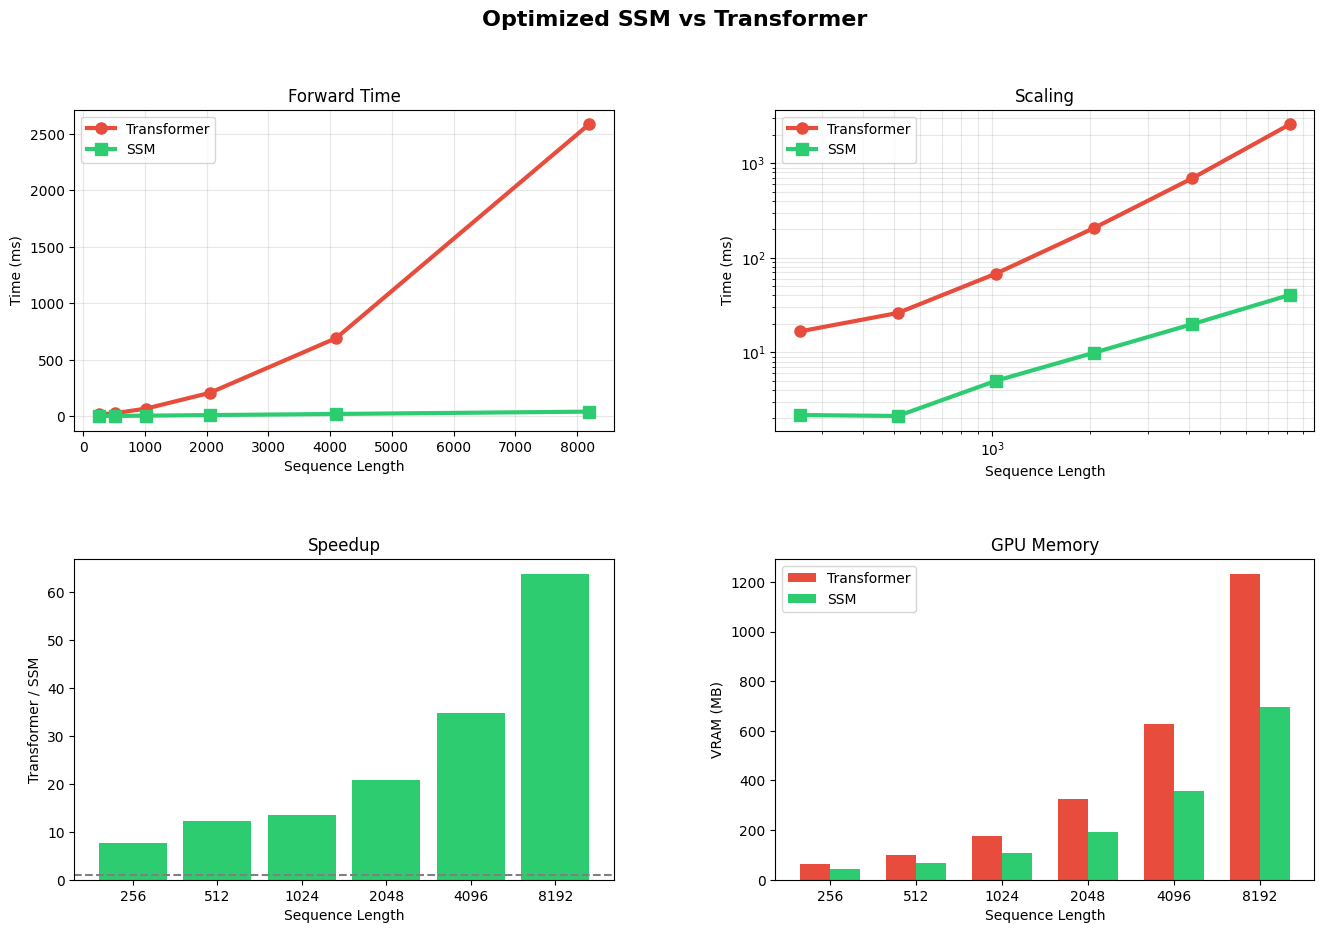


Saved : optimized_ssm_vs_transformer.png


In [ ]:
# ============================================================
# SIMPLE BENCHMARK : OPTIMIZED SSM vs TRANSFORMER
# Compatible partout (sans mamba_ssm)
# ============================================================

!pip install -q matplotlib numpy

# ============================================================
# IMPORTS
# ============================================================

import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================
# DEVICE
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 60)
print(f"Device : {device}")

if device == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(
        f"VRAM   : "
        f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB"
    )

print("=" * 60)

# ============================================================
# OPTIMIZATION
# ============================================================

torch.set_float32_matmul_precision("high")

# ============================================================
# CONFIG
# ============================================================

B = 16
D = 256

SEQ_LENGTHS = [
    256,
    512,
    1024,
    2048,
    4096,
    8192,
]

N_WARMUP = 5
N_RUNS = 15 if device == "cuda" else 5

# ============================================================
# TRANSFORMER
# ============================================================

class SimpleTransformer(nn.Module):

    def __init__(
        self,
        d_model=D,
        nhead=8,
        num_layers=4
    ):
        super().__init__()


 layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            layer,
            num_layers=num_layers
        )

    def forward(self, x):

        return self.encoder(x)

# ============================================================
# OPTIMIZED SSM
# ============================================================

class FastSSM(nn.Module):

    def __init__(
        self,
        d_model=D,
        expand=2
    ):
        super().__init__()

        inner = d_model * expand

        self.in_proj = nn.Linear(
            d_model,
            inner
        )

        self.conv = nn.Conv1d(
            inner,
            inner,
            kernel_size=4,
            padding=3,
            groups=inner
        )

        self.out_proj = nn.Linear(
            inner,
            d_model
        )

        self.gate = nn.Linear(
            d_model,
            inner
        )

    def forward(self, x):

        # x : [B,L,D]

        u = self.in_proj(x)

        # depthwise conv
        u = u.transpose(1, 2)

        u = self.conv(u)

        u = u[..., :x.shape[1]]

        u = u.transpose(1, 2)

        u = F.silu(u)

        # gating
        g = torch.sigmoid(
            self.gate(x)
        )

        y = u * g

        return self.out_proj(y)

# ============================================================
# BENCHMARK
# ============================================================

def benchmark(
    model,
    x,
    n_warmup=5,
    n_runs=10
):

    model.eval()

    with torch.no_grad():

        # warmup
        for _ in range(n_warmup):
            _ = model(x)

        if device == "cuda":
            torch.cuda.synchronize()
            torch.cuda.reset_peak_memory_stats()

        timings = []

        for _ in range(n_runs):

            if device == "cuda":
                torch.cuda.synchronize()

            t0 = time.perf_counter()

            _ = model(x)

            if device == "cuda":
                torch.cuda.synchronize()

            timings.append(
                (time.perf_counter() - t0) * 1000
            )

    mem = (
        torch.cuda.max_memory_allocated() / 1e6
        if device == "cuda"
        else 0
    )

    return np.median(timings), mem

# ============================================================
# CREATE MODELS
# ============================================================

print("\nCreating models...")

tf = SimpleTransformer().to(device)

ssm = FastSSM().to(device)

# compile optimization
tf = torch.compile(tf)

ssm = torch.compile(ssm)

n_tf = sum(p.numel() for p in tf.parameters()) / 1e6

n_ssm = sum(p.numel() for p in ssm.parameters()) / 1e6

print(f"\nTransformer params : {n_tf:.2f}M")
print(f"SSM params         : {n_ssm:.2f}M")

# ============================================================
# RESULTS STORAGE
# ============================================================

results = {

    "seq": [],

    "tf_time": [],
    "ssm_time": [],

    "tf_mem": [],
    "ssm_mem": [],
}

# ============================================================
# MAIN LOOP
# ============================================================

print("\n")

print(
    f"{'L':>8} | "
    f"{'Transformer':>14} | "
    f"{'SSM':>12} | "
    f"{'T-MEM':>10} | "
    f"{'S-MEM':>10} | "
    f"Speedup"
)

print("─" * 80)

for L in SEQ_LENGTHS:

    print(f"\nTesting sequence length = {L}")

    x = torch.randn(
        B,
        L,
        D
    ).to(device)

    tf_time, tf_mem = benchmark(
        tf,
        x,
        N_WARMUP,
        N_RUNS
    )

    ssm_time, ssm_mem = benchmark(
        ssm,
        x,
        N_WARMUP,
        N_RUNS
    )

    results["seq"].append(L)

    results["tf_time"].append(tf_time)
    results["ssm_time"].append(ssm_time)

    results["tf_mem"].append(tf_mem)
    results["ssm_mem"].append(ssm_mem)

    speedup = tf_time / ssm_time

    icon = "🟢" if speedup > 1 else "🔴"

    print(
        f"{L:>8} | "
        f"{tf_time:>11.2f} ms | "
        f"{ssm_time:>9.2f} ms | "
        f"{tf_mem:>8.0f} MB | "
        f"{ssm_mem:>8.0f} MB | "
        f"{icon} {speedup:.2f}×"
    )

# ============================================================
# VISUALIZATION
# ============================================================

COL_T = "#E74C3C"
COL_S = "#2ECC71"

seq = results["seq"]

fig = plt.figure(figsize=(16, 10))

gs = gridspec.GridSpec(
    2,
    2,
    figure=fig,
    hspace=0.4,
    wspace=0.3
)

fig.suptitle(
    "Optimized SSM vs Transformer",
    fontsize=16,
    fontweight="bold"
)

# ============================================================
# GRAPH 1
# ============================================================

ax1 = fig.add_subplot(gs[0, 0])

ax1.plot(
    seq,
    results["tf_time"],
    "o-",
    color=COL_T,
    lw=3,
    ms=8,
    label="Transformer"
)

ax1.plot(
    seq,
    results["ssm_time"],
    "s-",
    color=COL_S,
    lw=3,
    ms=8,
    label="SSM"
)

ax1.set_title("Forward Time")
ax1.set_xlabel("Sequence Length")
ax1.set_ylabel("Time (ms)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# ============================================================
# GRAPH 2
# ============================================================

ax2 = fig.add_subplot(gs[0, 1])

ax2.loglog(
    seq,
    results["tf_time"],
    "o-",
    color=COL_T,
    lw=3,
    ms=8,
    label="Transformer"
)

ax2.loglog(
    seq,
    results["ssm_time"],
    "s-",
    color=COL_S,
    lw=3,
    ms=8,
    label="SSM"
)

ax2.set_title("Scaling")
ax2.set_xlabel("Sequence Length")
ax2.set_ylabel("Time (ms)")
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

# ============================================================
# GRAPH 3
# ============================================================

ax3 = fig.add_subplot(gs[1, 0])

speedups = [

    t / s

    for t, s in zip(
        results["tf_time"],
        results["ssm_time"]
    )
]

colors = [
    COL_S if s > 1 else COL_T
    for s in speedups
]

bars = ax3.bar(
    range(len(seq)),
    speedups,
    color=colors
)

ax3.axhline(
    y=1,
    linestyle="--",
    color="gray"
)

ax3.set_xticks(
    range(len(seq))
)

ax3.set_xticklabels(seq)

ax3.set_title("Speedup")
ax3.set_xlabel("Sequence Length")
ax3.set_ylabel("Transformer / SSM")

# ============================================================
# GRAPH 4
# ============================================================

ax4 = fig.add_subplot(gs[1, 1])

x_pos = np.arange(len(seq))

w = 0.35

ax4.bar(
    x_pos - w/2,
    results["tf_mem"],
    width=w,
    color=COL_T,
    label="Transformer"
)

ax4.bar(
    x_pos + w/2,
    results["ssm_mem"],
    width=w,
    color=COL_S,
    label="SSM"
)

ax4.set_xticks(x_pos)

ax4.set_xticklabels(seq)

ax4.set_title("GPU Memory")
ax4.set_xlabel("Sequence Length")
ax4.set_ylabel("VRAM (MB)")
ax4.legend()

plt.savefig(
    "optimized_ssm_vs_transformer.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nSaved : optimized_ssm_vs_transformer.png")